<a href="https://colab.research.google.com/github/banujan14/Nasreen/blob/test/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow yfinance

Installing numpy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import yfinance as yf

Importing Liabraries

In [ ]:
data = yf.download("SBIN.NS", start="2020-01-01", end="2026-04-20")
data = data[['Close']]
data.head()

/tmp/ipykernel_2532/953700769.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SBIN.NS", start="2020-01-01", end="2026-04-20")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,SBIN.NS
Date,
2020-01-01,308.602570
2020-01-02,313.077759
2020-01-03,307.910492
2020-01-06,294.346619
2020-01-07,293.792938


Data loading for stock of SBI

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

Scaling and Normalizing data

In [ ]:
def create_dataset(data, time_step=60):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

create data set with time

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

Reshaping with values

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Building RNN

In [ ]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.6670e-04
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.4858e-04
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.0844e-04
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.7988e-04
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.0071e-04
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.1906e-04
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.4960e-04
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.4087e-04
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.2030e-04
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.2368e-04


Training the Model

In [ ]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

predicted_price = model.predict(last_60_days)
predicted_price = scaler.inverse_transform(predicted_price)

print("Predicted Price:", predicted_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Predicted Price: [[1032.9587]]


Prediction of price

In [ ]:
future_days = 10
time_step = 60

# Initialize temp_input with the last 'time_step' values, shaped as (1, time_step)
temp_input = scaled_data[-time_step:].reshape(1, time_step)

output = []

try:
    for _ in range(future_days):
        # Reshape temp_input for the LSTM model (1, time_step, 1)
        x_input = temp_input.reshape((1, time_step, 1))

        # Get the prediction for the next day
        yhat = model.predict(x_input)

        # Append the predicted value (scalar) to our output list
        output.append(yhat[0][0])

        # Update temp_input: remove the oldest value and add the new prediction
        temp_input = np.append(temp_input[:, 1:], np.array([[yhat[0][0]]]), axis=1)

    predicted_values = scaler.inverse_transform(np.array(output).reshape(-1,1))
    print(predicted_values)
except Exception as e:
    print(f"An error occurred during prediction: {e}")
    predicted_values = np.array([]) # Ensure predicted_values is defined even on error


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[1032.9587 ]
 [1035.0049 ]
 [1034.2256 ]
 [1031.4915 ]
 [1027.4153 ]
 [1022.43787]
 [1016.872  ]
 [1010.93396]
 [1004.773  ]
 [ 998.4915 ]]


Prediction of Multiple days

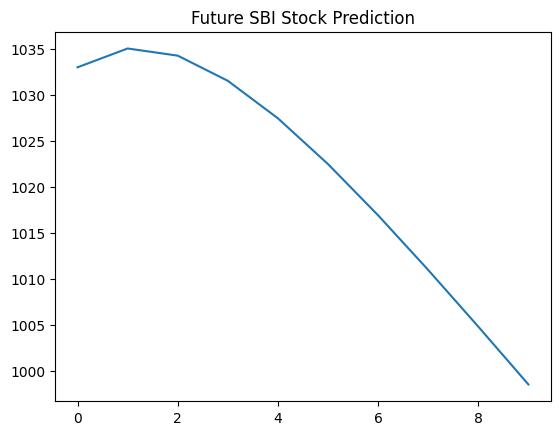

In [ ]:
plt.plot(predicted_values)
plt.title("Future SBI Stock Prediction")
plt.show()

Predicted values displaying in plot